# 03 — ECG & PPG Signal Processing

**Goal**: Process raw physiological signals from wearable sensors.

Real wearable signals are corrupted by:
- Motion artifacts
- Baseline wander (slow drift)
- Powerline interference (50/60 Hz)

This notebook implements a full preprocessing and feature extraction pipeline.

---

## Pipeline
1. Simulate realistic ECG and PPG signals
2. Apply Butterworth bandpass filter
3. Estimate power spectral density (Welch method)
4. Detect R-peaks (ECG) and pulse peaks (PPG)
5. Derive heart rate from detected peaks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
import warnings
warnings.filterwarnings('ignore')


In [3]:
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.5,
    'axes.grid':        True,
})

In [4]:

BLUE   = '#58a6ff'
GREEN  = '#3fb950'
RED    = '#f78166'
PURPLE = '#d2a8ff'
ORANGE = '#ffa657'
MUTED  = '#8b949e'

np.random.seed(42)
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Simulate ECG Signal

We model the PQRST complex as a sum of Gaussians — a standard synthetic ECG approach.
Then we add realistic noise: Gaussian noise + 50 Hz powerline interference + baseline wander.

In [5]:
FS  = 250   # sampling frequency (Hz)
DUR = 10.0  # duration (seconds)
t   = np.linspace(0, DUR, int(FS * DUR))

def make_ecg(t, hr=68):
    """Synthetic ECG via sum of Gaussians for PQRST complex."""
    period = 60 / hr
    ecg = np.zeros_like(t)
    for beat in np.arange(0, t[-1], period):
        ecg += 0.15 * np.exp(-0.5 * ((t - beat - 0.10) / 0.040) ** 2)  # P
        ecg -= 0.05 * np.exp(-0.5 * ((t - beat - 0.17) / 0.015) ** 2)  # Q
        ecg += 1.20 * np.exp(-0.5 * ((t - beat - 0.20) / 0.020) ** 2)  # R
        ecg -= 0.25 * np.exp(-0.5 * ((t - beat - 0.23) / 0.020) ** 2)  # S
        ecg += 0.35 * np.exp(-0.5 * ((t - beat - 0.35) / 0.060) ** 2)  # T
    return ecg

ecg_clean = make_ecg(t, hr=68)

# Add realistic noise
noise_gaussian  = np.random.normal(0, 0.15, len(t))          # muscle noise
noise_powerline = 0.20 * np.sin(2 * np.pi * 50 * t)          # 50 Hz interference
noise_baseline  = 0.30 * np.sin(2 * np.pi * 0.3 * t)         # baseline wander
ecg_noisy = ecg_clean + noise_gaussian + noise_powerline + noise_baseline

print(f'Signal length : {len(t)} samples')
print(f'Duration      : {DUR:.0f} s at {FS} Hz')
print(f'SNR (approx)  : {10*np.log10(np.var(ecg_clean)/np.var(noise_gaussian)):.1f} dB')

Signal length : 2500 samples
Duration      : 10 s at 250 Hz
SNR (approx)  : 3.5 dB


## 2. Bandpass Filter

A 4th-order Butterworth bandpass filter (0.5–40 Hz) removes:
- Baseline wander (below 0.5 Hz)
- High-frequency noise and powerline (above 40 Hz)

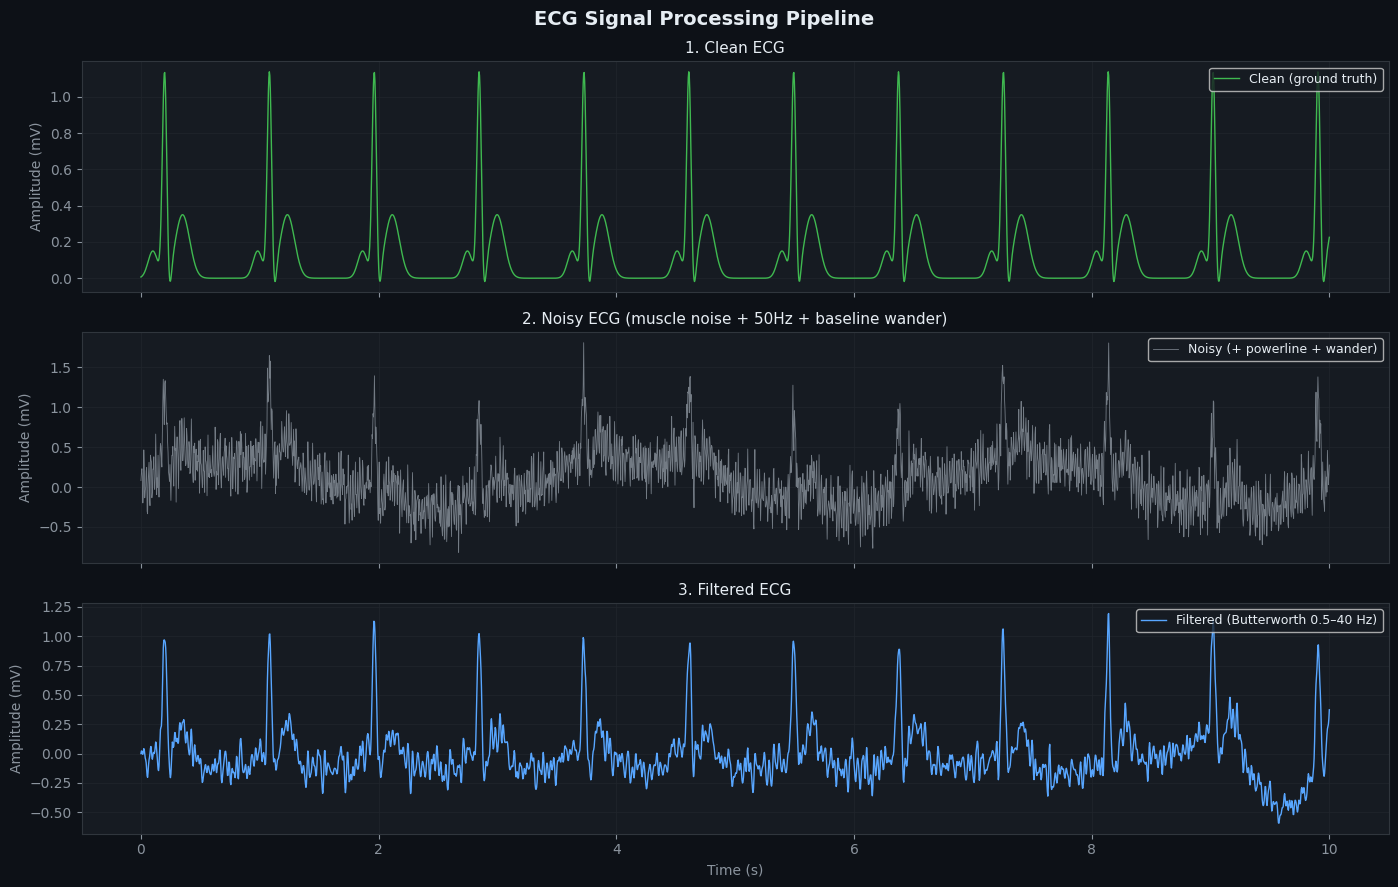

In [6]:
def bandpass_filter(sig, lowcut=0.5, highcut=40.0, fs=250, order=4):
    """Zero-phase Butterworth bandpass filter."""
    sos = signal.butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, sig)  # sosfiltfilt = zero-phase (no delay)

ecg_filtered = bandpass_filter(ecg_noisy, lowcut=0.5, highcut=40.0, fs=FS)

# Plot: raw vs filtered
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('ECG Signal Processing Pipeline', fontsize=14, fontweight='bold', y=0.98)

axes[0].plot(t, ecg_clean,    color=GREEN,  lw=1.0, label='Clean (ground truth)')
axes[0].set_title('1. Clean ECG', fontsize=11)
axes[0].legend(loc='upper right', facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)

axes[1].plot(t, ecg_noisy,    color=MUTED,  lw=0.6, alpha=0.8, label='Noisy (+ powerline + wander)')
axes[1].set_title('2. Noisy ECG (muscle noise + 50Hz + baseline wander)', fontsize=11)
axes[1].legend(loc='upper right', facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)

axes[2].plot(t, ecg_filtered, color=BLUE,   lw=1.0, label='Filtered (Butterworth 0.5–40 Hz)')
axes[2].set_title('3. Filtered ECG', fontsize=11)
axes[2].legend(loc='upper right', facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)
axes[2].set_xlabel('Time (s)')

for ax in axes:
    ax.set_ylabel('Amplitude (mV)')

plt.tight_layout()
plt.savefig('../figures/03_ecg_filtering.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 3. Power Spectral Density (Welch Method)

The Welch method estimates PSD by averaging periodograms over overlapping windows.
This clearly shows where noise energy sits in the frequency domain.

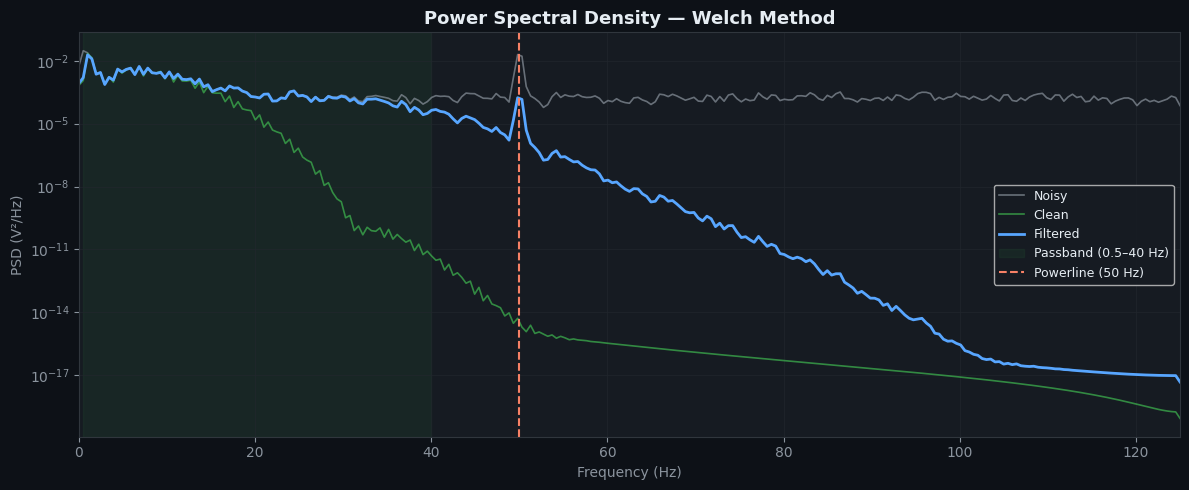

In [7]:
freqs_n, psd_n = signal.welch(ecg_noisy,    fs=FS, nperseg=512)
freqs_f, psd_f = signal.welch(ecg_filtered, fs=FS, nperseg=512)
freqs_c, psd_c = signal.welch(ecg_clean,    fs=FS, nperseg=512)

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(freqs_n, psd_n, color=MUTED,  lw=1.2, alpha=0.7, label='Noisy')
ax.semilogy(freqs_c, psd_c, color=GREEN,  lw=1.2, alpha=0.7, label='Clean')
ax.semilogy(freqs_f, psd_f, color=BLUE,   lw=2.0,            label='Filtered')
ax.axvspan(0.5, 40, alpha=0.07, color=GREEN, label='Passband (0.5–40 Hz)')
ax.axvline(50, color=RED, lw=1.5, ls='--', label='Powerline (50 Hz)')
ax.set_xlim(0, FS // 2)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (V²/Hz)')
ax.set_title('Power Spectral Density — Welch Method', fontsize=13, fontweight='bold')
ax.legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/03_psd_welch.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 4. R-Peak Detection

R-peaks are the dominant peaks in each heartbeat. Detecting them lets us compute:
- **Heart rate** (HR) from inter-peak intervals
- **RR intervals** for HRV analysis

R-peaks detected : 12
Mean HR          : 68.0 bpm
Mean RR interval : 882.9 ms
RMSSD            : 17.9 ms


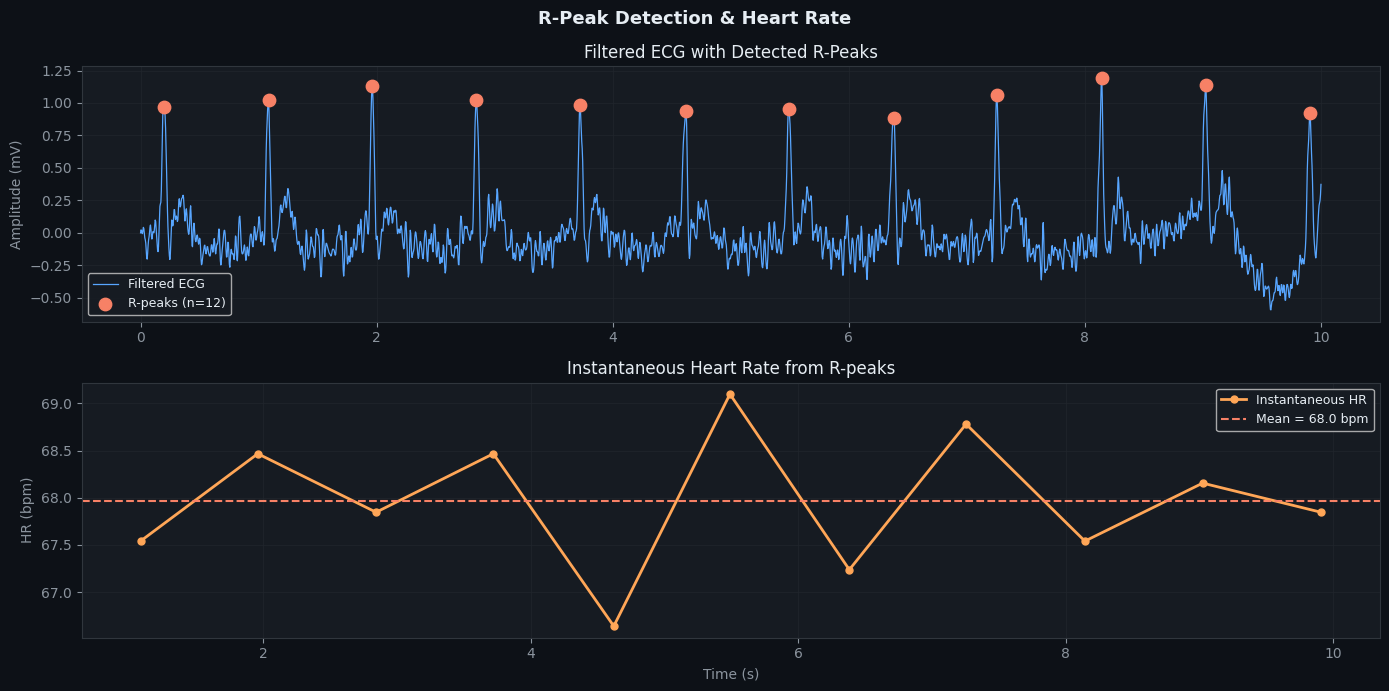

In [8]:
def detect_rpeaks(ecg, fs=250, min_hr=40, max_hr=200):
    """Simple R-peak detector using scipy find_peaks."""
    min_distance = int(fs * 60 / max_hr)  # minimum samples between peaks
    threshold    = 0.5 * np.max(ecg)      # 50% of max amplitude
    peaks, props = signal.find_peaks(ecg, distance=min_distance, height=threshold)
    return peaks

rpeaks = detect_rpeaks(ecg_filtered, fs=FS)
rr_intervals_ms = np.diff(t[rpeaks]) * 1000  # convert to milliseconds
hr_bpm = 60 / np.diff(t[rpeaks])

print(f'R-peaks detected : {len(rpeaks)}')
print(f'Mean HR          : {hr_bpm.mean():.1f} bpm')
print(f'Mean RR interval : {rr_intervals_ms.mean():.1f} ms')
print(f'RMSSD            : {np.sqrt(np.mean(np.diff(rr_intervals_ms)**2)):.1f} ms')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('R-Peak Detection & Heart Rate', fontsize=13, fontweight='bold')

axes[0].plot(t, ecg_filtered, color=BLUE, lw=0.9, label='Filtered ECG')
axes[0].scatter(t[rpeaks], ecg_filtered[rpeaks], color=RED, s=80, zorder=5,
                label=f'R-peaks (n={len(rpeaks)})')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].set_title('Filtered ECG with Detected R-Peaks')
axes[0].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)

axes[1].plot(t[rpeaks[1:]], hr_bpm, color=ORANGE, lw=2, marker='o', ms=5, label='Instantaneous HR')
axes[1].axhline(hr_bpm.mean(), color=RED, lw=1.5, ls='--', label=f'Mean = {hr_bpm.mean():.1f} bpm')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('HR (bpm)')
axes[1].set_title('Instantaneous Heart Rate from R-peaks')
axes[1].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/03_rpeak_detection.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5. PPG Signal Processing

Photoplethysmography (PPG) measures blood volume pulse optically.
Wrist-based wearables (Fitbit, Apple Watch) use PPG — not ECG.
Peak detection on PPG gives heart rate without electrodes.

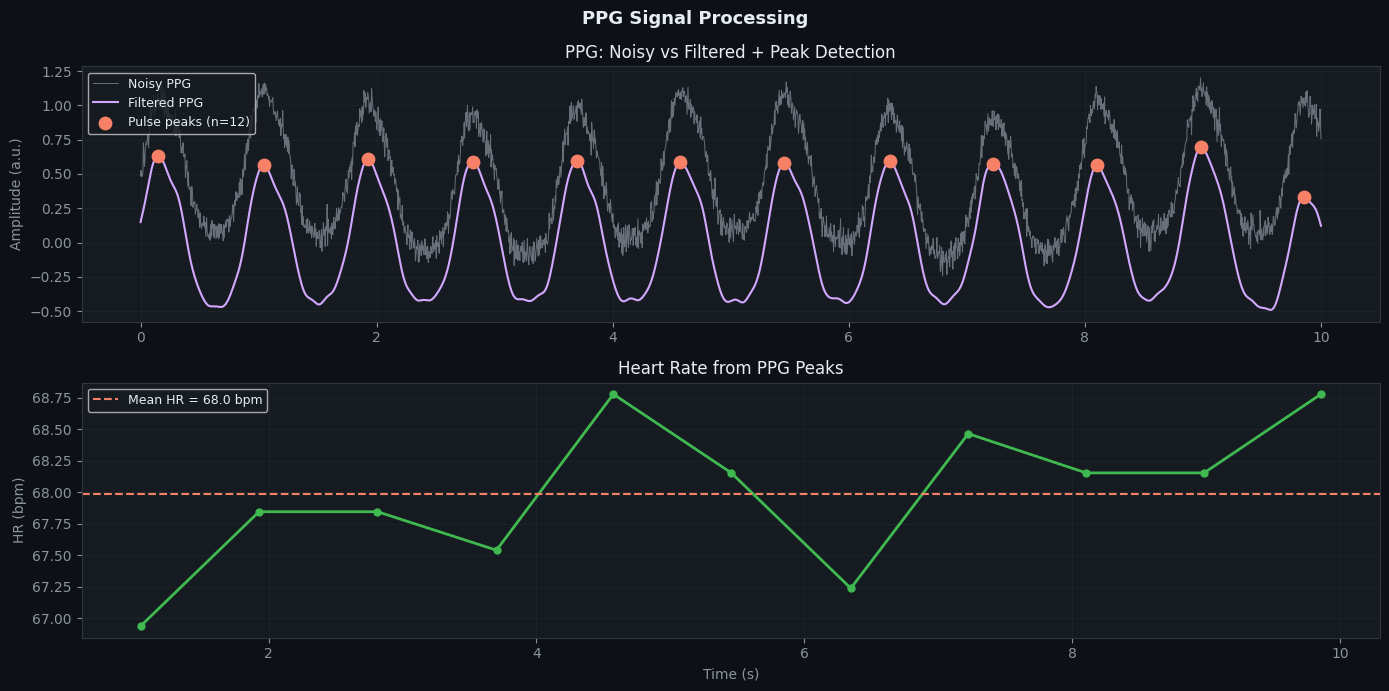

PPG HR estimate : 68.0 bpm


In [9]:
# Simulate PPG: slower, smoother than ECG
hr_ppg = 68
period_ppg = 60 / hr_ppg
ppg = np.zeros_like(t)
for beat in np.arange(0, t[-1], period_ppg):
    ppg += np.exp(-0.5 * ((t - beat - 0.15) / 0.12) ** 2)  # systolic peak
    ppg += 0.4 * np.exp(-0.5 * ((t - beat - 0.35) / 0.08) ** 2)  # dicrotic notch

ppg_noisy = ppg + np.random.normal(0, 0.05, len(t)) + 0.1 * np.sin(2 * np.pi * 0.25 * t)

# Filter PPG (lower frequency content than ECG)
sos_ppg = signal.butter(4, [0.5, 8.0], btype='bandpass', fs=FS, output='sos')
ppg_filtered = signal.sosfiltfilt(sos_ppg, ppg_noisy)

# Detect PPG peaks
ppg_peaks, _ = signal.find_peaks(ppg_filtered,
                                  distance=int(FS * 0.5),
                                  height=np.percentile(ppg_filtered, 60))
hr_ppg_detected = 60 / np.diff(t[ppg_peaks])

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('PPG Signal Processing', fontsize=13, fontweight='bold')

axes[0].plot(t, ppg_noisy,    color=MUTED,   lw=0.7, alpha=0.7, label='Noisy PPG')
axes[0].plot(t, ppg_filtered, color=PURPLE,  lw=1.5,            label='Filtered PPG')
axes[0].scatter(t[ppg_peaks], ppg_filtered[ppg_peaks],
                color=RED, s=80, zorder=5, label=f'Pulse peaks (n={len(ppg_peaks)})')
axes[0].set_ylabel('Amplitude (a.u.)')
axes[0].set_title('PPG: Noisy vs Filtered + Peak Detection')
axes[0].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)

axes[1].plot(t[ppg_peaks[1:]], hr_ppg_detected, color=GREEN, lw=2, marker='o', ms=5)
axes[1].axhline(hr_ppg_detected.mean(), color=RED, lw=1.5, ls='--',
                label=f'Mean HR = {hr_ppg_detected.mean():.1f} bpm')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('HR (bpm)')
axes[1].set_title('Heart Rate from PPG Peaks')
axes[1].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/03_ppg_processing.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'PPG HR estimate : {hr_ppg_detected.mean():.1f} bpm')

## 6. Summary

| Step | Method | Key parameter |
|------|--------|---------------|
| Filtering | Butterworth bandpass | 0.5–40 Hz (ECG), 0.5–8 Hz (PPG) |
| Spectral analysis | Welch PSD | nperseg=512 |
| R-peak detection | scipy.find_peaks | distance=min 300ms, height=50% max |
| PPG peaks | scipy.find_peaks | distance=500ms, height=60th percentile |

**Key takeaway**: Zero-phase filtering (sosfiltfilt) preserves peak timing, which is critical for accurate HRV computation.

➡️ **Next**: Notebook 04 — Sleep staging & cardiac dynamics during sleep